# Liraries

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd

# Dataset upload

In [14]:
df = pd.read_excel('rccarbonation.xlsx')
df = df.rename(columns={'Possan': 'carb. depth (mm)'})
df = df.rename(columns={'CCO₂ (%)': 'CO2 (%)'})
df.head()

,CO2 (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),carb. depth (mm)
0,0.08,25.9,35.4,CPII Z,PIA,9,10.1384
1,0.07,21.7,43.8,CPV - ARI,UEA,92,23.2231
2,0.08,30.3,83.7,CPIV,UEA,58,13.2715
3,0.15,22.8,37.6,CPIV,PIA,42,45.1498
4,0.03,26.4,65.2,CPII F,UEA,96,22.6178


### Convert categorical text data to numeric codes 

In [15]:
mapping_dict = {
                    r'\bPIA\b': '0', r'\bUEA\b': '1', r'\bPEA\b': '2',
                    r'\bCPII Z\b': '0', r'\bCPV - ARI\b': '1', r'\bCPIV\b': '2',
                    r'\bCPII F\b': '3', r'\bCPIII\b': '4', r'\bCPII E\b': '5',
               }
df.replace(mapping_dict, regex=True, inplace=True)    
for col in ['Exposure conditions', 'Type of cement']:
    df[col] = pd.to_numeric(df[col])
df.head()

,CO2 (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),carb. depth (mm)
0,0.08,25.9,35.4,0,0,9,10.1384
1,0.07,21.7,43.8,1,1,92,23.2231
2,0.08,30.3,83.7,2,1,58,13.2715
3,0.15,22.8,37.6,2,0,42,45.1498
4,0.03,26.4,65.2,3,1,96,22.6178


# Descriptive Statistics

### Central tendency (mean, median) and dispersion (standard deviation)

In [16]:
stats = df.describe().T
stats = stats[['mean', 'std', 'min', 'max']]
stats

,mean,std,min,max
CO2 (%),0.164796,0.078089,0.03,0.3000
fc (MPa),34.900490,8.662669,20.00,50.0000
RH (%),59.939055,17.305382,30.00,90.0000
Type of cement,2.506900,1.705725,0.00,5.0000
Exposure conditions,0.992100,0.816377,0.00,2.0000
t (years),49.933550,29.320048,0.00,100.0000
carb. depth (mm),16.591604,12.842477,0.00,119.7121


### Plot in LateX

In [17]:
latex = stats.to_latex(float_format="%.2f")
print(latex)

\begin{tabular}{lrrrr}
\toprule
 & mean & std & min & max \\
\midrule
CO2 (%) & 0.16 & 0.08 & 0.03 & 0.30 \\
fc (MPa) & 34.90 & 8.66 & 20.00 & 50.00 \\
RH (%) & 59.94 & 17.31 & 30.00 & 90.00 \\
Type of cement & 2.51 & 1.71 & 0.00 & 5.00 \\
Exposure conditions & 0.99 & 0.82 & 0.00 & 2.00 \\
t (years) & 49.93 & 29.32 & 0.00 & 100.00 \\
carb. depth (mm) & 16.59 & 12.84 & 0.00 & 119.71 \\
\bottomrule
\end{tabular}



### Correlation Analysis

The Heatmap below visualizes the Pearson correlation coefficients between variables.
* **Positive values (blue):** Indicate a direct relationship (e.g., as Time increases, Carbonation Depth increases).
* **Negative values (red):** Indicate an inverse relationship (e.g., higher Compressive Strength reduces Carbonation).

#### Correlation data

In [18]:
corr_matrix = df.corr()

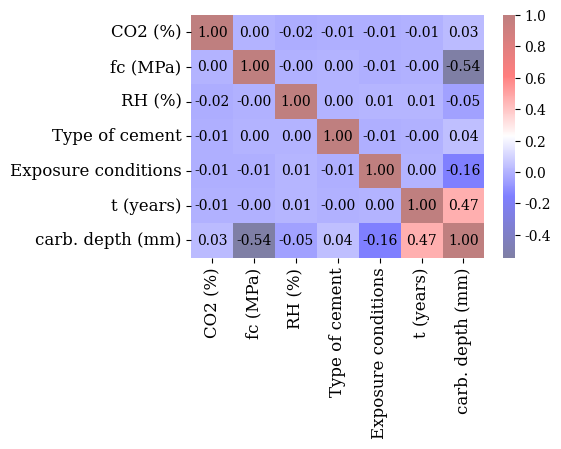

In [ ]:
### Figure name and DPI
dpi = 600                                                   # Change as you wish
name = 'correlation_heatmap'                                # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 12                                                   # Change as you wish
h_cm = 8                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
size_axis = 12                                              # Change as you wish
color_axis = 'black'                                        # or hexadecimal. Change as you wish

### Cmap
cmap = 'seismic'                                            # Change as you wish. Check matplotlib colormaps documentation: https://matplotlib.org/stable/users/explain/colors/colormaps.html
fmt = ".2f"                                                 # Change as you wish
anot = True                                                # Change as you wish
alpha = 0.5                                                 # Change as you wish
color_annot = 'black'                                       # or hexadecimal. Change as you wish

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)

### Title. Do you need a title? Use the cell bellow:
# ax.set_title('Sine Wave Plot', fontsize=16)

### Plot data and legend
sns.heatmap(corr_matrix, 
            annot=anot, 
            fmt=fmt, 
            cmap=cmap, 
            alpha=alpha, annot_kws={"color": color_annot})


### Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Numerical variables PDF

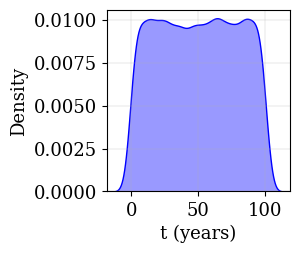

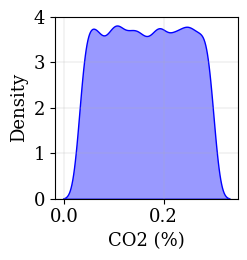

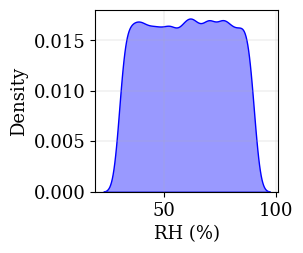

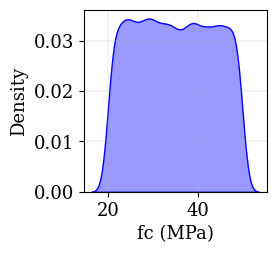

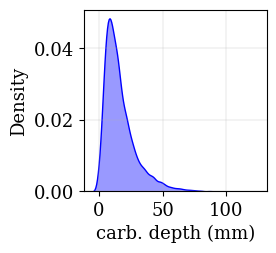

In [ ]:
# List of features to analyze
features = ['t (years)', 'CO2 (%)', 'RH (%)', 'fc (MPa)', 'carb. depth (mm)']
names = ['time', 'CO2_concentration', 'relative_humidity', 'compressive_strength', 'carbonation_depth']

for i, feature in enumerate(features):
    ### Figure name and DPI
    dpi = 600                                                                               # Change as you wish
    name = f'z_kde_histogram_{names[i]}' # Change as you wish
    
    ### Chart dimensions (in centimeters)
    b_cm = 6                                                   # Change as you wish
    h_cm = 6                                                    # Change as you wish
    inches_to_cm = 1 / 2.54
    b_input = b_cm * inches_to_cm
    h_input = h_cm * inches_to_cm

    ### Axis and labels (For LateX font format use the dollar sign $)
    label_y = 'Density'
    label_x = f'{feature}'                   # Change as you wish     
    size_label = 13                     # Change as you wish
    color_label = 'black'               # or hexadecimal. Change as you wish
    size_axis = 13                      # Change as you wish
    color_axis = 'black'                # or hexadecimal. Change as you wish

    ### Color KDE
    color = ['blue']                    # or hexadecimal. Change as you wish
    alpha = 0.4                         # Change as you wish

    ### Figure
    fig, ax = plt.subplots(figsize=(b_input, h_input))
    # Config axis
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
    ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

    # Config grid
    on_or_off = True
    plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)

    # Plot data'Densidade'
    sns.kdeplot(data=df, x=feature, fill=True, alpha=alpha, ax=ax, color=color[0])

    # Save. Do you need save? Use the cell bellow:
    fig.savefig(f'z_kde_{names[i]}_en.png', dpi=dpi, bbox_inches='tight')
    plt.show()